In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt


In [2]:
#importing libraries

import warnings
warnings.filterwarnings("ignore")
import pandas as pd    
import numpy as n  
import matplotlib
import matplotlib.pyplot as plt    
import seaborn as sns  
import scipy    
import statsmodels.formula.api as smf    
import statsmodels.api as sm  
from sklearn.preprocessing import robust_scale
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
## for explainer    
from lime import lime_tabular
from mlxtend.preprocessing import minmax_scaling
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing.data import QuantileTransformer
from scipy.stats import skew

In [3]:
#import data as df
df_train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
df_test_main = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
df_train


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
df_test_main

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [5]:
#df = df.drop(df[df['SalePrice'] > 350000].index)

In [6]:
df = pd.concat((df_train.loc[:,'MSSubClass':'SaleCondition'], df_test_main.loc[:,'MSSubClass':'SaleCondition']))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f86b8bc43d0>,
      dtype=object)

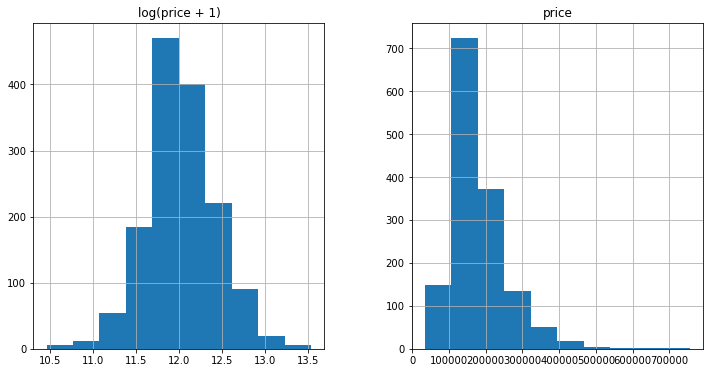

In [7]:
## checking for normal distribution of saleprice
matplotlib.rcParams['figure.figsize'] = (12.0, 6.0)
prices = pd.DataFrame({"price":df_train["SalePrice"], "log(price + 1)":np.log1p(df_train["SalePrice"])})
prices.hist()

In [8]:
#log transform the target saleprice:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])

In [9]:
##preliminary feature engeneering

df['BsmtQual'] = df['BsmtQual'].fillna(1) # we have some NaNs there - let's replace them to 1
df['GarageType'] = df['GarageType'].fillna(1) # we have some NaNs there - let's replace them to 1
df['GarageFinish'] = df['GarageFinish'].fillna(1) # we have some NaNs there - let's replace them to 1
df['FireplaceQu'] = df['FireplaceQu'].fillna(1) # we have some NaNs there - let's replace them to 1
df = df.replace({"BsmtQual" : { "Po" : 1, "Fa" : 2, "TA": 3, "Gd" : 4, "Ex" : 5}, "ExterQual" : {"Po" : 1, "Fa" : 2, "TA": 3, "Gd": 4, "Ex" : 5}, "KitchenQual" : {"Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}})
df = df.replace({'GarageType': {'Detchd' : 1, 'CarPort': 2, 'BuiltIn': 3, 'Basment': 4, 'Attchd': 5, '2Types': 6}})
df = df.replace({'GarageFinish': {'Unf' : 1, 'RFn': 2, ' Fin': 3}})
df = df.replace({'HeatingQC': {'Po' : 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}})
df = df.replace({'Foundation': {'Wood' : 1, 'Stone': 5, 'Slab': 2, 'BrkTil': 3, 'CBlock': 4, 'PConc': 6}})
df = df.replace({'PavedDrive': {'N' : 1, 'P': 2, ' Y': 3}})
df['ExterQual'] = df['ExterQual'].astype(object)
df = df.replace({'ExterQual': {'Po' : 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}})
#df = df.replace({'ExterCond': {'Po' : 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}}) # not actual feature
#df['Exter'] = df['ExterQual']*df['ExterCond'] #worse
df['YearRemodAdd'] = df['YearRemodAdd']/2000


df['Bath'] = df["BsmtFullBath"] + (0.5 * df["BsmtHalfBath"]) + df["FullBath"] + (0.5 * df["HalfBath"])

df = df.replace({'FireplaceQu': {'Po' : 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}})


df['YrBltAndRemod']=(df['YearBuilt']+df['YearRemodAdd'])/2000
df['MSSubClass'] = df['MSSubClass'].apply(str)
df['YrSold'] = df['YrSold'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)
df["Functional"] = df["Functional"].fillna("Typ")
df['MSSubClass'] = df['MSSubClass'].apply(str)
df['OverallCond'] = df['OverallCond'].astype(str)

## imputing NaNs for GarageYrBlt 
#start
df['YearBuiltCut'] = pd.qcut(df['YearBuilt'], 10)
df['GarageYrBlt'] = df.groupby(['YearBuiltCut'])['GarageYrBlt'].transform(lambda x : x.fillna(x.median()))
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)/2000
df.drop('YearBuiltCut', axis=1, inplace=True)
#end

df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace = True)
df['MasVnrArea'].fillna(df['MasVnrArea'].median(), inplace = True)
df['Bath'].fillna(df['Bath'].median(), inplace = True)
df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median(), inplace = True)
df['GarageArea'].fillna(df['GarageArea'].median(), inplace = True)
df['GarageCars'].fillna(df['GarageCars'].median(), inplace = True)
df['KitchenQual'].fillna(df['KitchenQual'].median(), inplace = True)
df['BsmtFinSF1'].fillna(df['BsmtFinSF1'].median(), inplace = True)

df['BsmtUnfSF'].fillna(df['BsmtUnfSF'].median(), inplace = True)
df['LotFrontage'] = df['LotFrontage'].astype(int)
df['BsmtQual'] = df['BsmtQual'].fillna(1) # we have some NaNs (no basement = 1 category)

#df = df.drop(df[df['GrLivArea'] > 3500].index)
#df = df.drop(df[df['GarageArea'] > 1200].index)
#df = df.drop(df[df['TotalBsmtSF'] > 2400].index)

df["AllSF"] = df["GrLivArea"] + df["TotalBsmtSF"]
df['Garage'] = df['GarageCars'] * df['GarageArea'] 
df["WoodDeckSF"] = df["WoodDeckSF"].fillna(0)
df["OpenPorchSF"] = df["OpenPorchSF"].fillna(0)



#df = df.drop(df[df['Garage'] > 3500].index)
#df['Front*Area'] = df['LotFrontage'] * df['LotArea'] ##worse
#df = df.drop(df[df['AllSF'] > 4000].index)

def year_category(yb):
    if yb <= 1910:
        return 1
    elif yb <= 1950 and yb > 1910:
        return 2
    elif yb >= 1950 and yb < 1980:
        return 3
    elif yb >= 1980 and yb < 2000:
        return 4
    return 5

#df['YearBuilt_cat'] = df['YearBuilt'].apply(year_category) # not actual

df["Qual"] = df["ExterQual"] * df["KitchenQual"] * df["BsmtQual"]
#df['OverallQual_2'] = df['OverallQual']**2 #worse
#df['OverallQual_3'] = df['OverallQual']**3 
#df["OverallQual-Sq"] = np.sqrt(df["OverallQual"]) #worse
#df['OverallQual_log'] = np.log1p('OverallQual')
df['FinalQual'] = df['OverallQual']*df['Qual']
df['Fireplaces-Sq'] = np.sqrt(df['Fireplaces'])
df['FireRooms'] = df['TotRmsAbvGrd']*df['Fireplaces-Sq']
df['Area'] = df['LotArea']*df['LotFrontage']

## final feature engeneering


#df["Qual"] = df["ExterQual"] * df["KitchenQual"] * df["BsmtQual"]
#df['OverallQual_2'] = df['OverallQual']**2
#df['OverallQual_3'] = df['OverallQual']**3 
#df["OverallQual-Sq"] = np.sqrt(df["OverallQual"]) #worse
#df['OverallQual_log'] = np.log1p('OverallQual')


#df['AllSF_2'] = df['AllSF']**2 ##worse
#df['AllSF_3'] = df['AllSF']**3 ## worse
#df['AllSF-Sq'] = np.sqrt(df['AllSF']) ##worse
#df['AllSF-log'] = np.log1p(df['AllSF'])

#df['GarageArea_2'] = df['GarageArea']**2 #worse
#df['GarageArea_3'] = df['GarageArea']**3 #worse
#df['GarageArea-Sq'] = np.sqrt(df['GarageArea']) #worse

#df['YearBuilt_cat_2'] = df['YearBuilt_cat']**2 #worse
#df['YearBuilt_cat_3'] = df['YearBuilt_cat']**3 #worse
#df['YearBuilt_cat-Sq'] = np.sqrt(df['YearBuilt_cat']) #worse

#df['Qual_2'] = df['Qual']**2 
#df['Qual_3'] = df['Qual']**3
#df['Qual-Sq'] = np.sqrt(df['Qual']) 

#df['Bath_2'] = df['Bath']**2 
#df['Bath_3'] = df['Bath']**3
#df['Bath-Sq'] = np.sqrt(df['Bath']) 

#df['Garage_2'] = df['Garage']**2 
#df['Garage_3'] = df['Garage']**3
#df['Garage-Sq'] = np.sqrt(df['Garage']) 

#df['FinalQual'] = df['OverallQual_2']*df['Qual']
#df['FinalQual1'] = df['OverallQual']*df['Qual-Sq']
#df['FinalQual2'] = df['OverallQual_2']*df['Qual']
#df['FinalQual3'] = df['OverallQual']*df['Qual']


#df['Fireplaces_2'] = df['Fireplaces']**2 
#df['Fireplaces_3'] = df['Fireplaces']**3
#df['Fireplaces-Sq'] = np.sqrt(df['Fireplaces'])

#df['FireRooms'] = df['TotRmsAbvGrd']*df['Fireplaces-Sq']

#df['OpenPorchSF_2'] = df['OpenPorchSF']**2 
#df['OpenPorchSF_3'] = df['OpenPorchSF']**3
#df['OpenPorchSF-Sq'] = np.sqrt(df['OpenPorchSF']) 
#df['OpenPorchSF-log'] = np.log1p(df['OpenPorchSF'])

#df['FinalQual-log'] = np.log1p(df['FinalQual']) 

#scaler = RobustScaler()
#df['AllSF'] = scaler.fit_transform(df[['AllSF']])

#scaler = StandardScaler()
#df[['Garage', 'Y', 'AllSF']] = scaler.fit_transform(df[['Garage', 'Y', 'AllSF']])

#df['Y'] = np.log1p(df['Y'])


#df['Foundation_2'] = df['Foundation']**2 
#df['Foundation_3'] = df['Foundation']**3
#df['Foundation-Sq'] = np.sqrt(df['Foundation'])
#df['Foundation-log'] = np.log1p(df['Foundation'])



In [10]:
# delete features from df with zero-values more than 50%
df = df.loc[:, ((df == 0).sum(axis=0) <= len(df.index)*0.6)]
# removing objects with nan-values more than 50% in frame
df = df.loc[:, (df.isnull().sum(axis=0) <= len(df.index)*0.6)]

# checking for Object columns
object_columns = df.select_dtypes(include=[np.object])



# replace NaNs with "None"
for col in object_columns:
    object_columns[col].fillna('None', inplace = True)
    
# replace 0 to median

df.replace(0,df.median(axis=0),inplace=True)

# checking for NANs in objects

object_columns.isnull().sum().sort_values(ascending = False).head()

SaleCondition    0
SaleType         0
RoofMatl         0
RoofStyle        0
OverallCond      0
dtype: int64

In [11]:
#log transform skewed numeric features:
numerical_features = df.select_dtypes(exclude = ["object"]).columns
num = df[numerical_features]

# Log transform of the skewed numerical features to lessen impact of outliers
# Inspired by Alexandru Papiu's script : https://www.kaggle.com/apapiu/house-prices-advanced-regression-techniques/regularized-linear-models
# As a general rule of thumb, a skewness with an absolute value > 0.5 is considered at least moderately skewed
skewness = num.apply(lambda x: skew(x))
skewness = skewness[abs(skewness) > 0.5]
print(str(skewness.shape[0]) + " skewed numerical features to log transform")
skewed_features = skewness.index
df[skewed_features] = np.log1p(df[skewed_features])


26 skewed numerical features to log transform


In [12]:
# Apply label encoder for category columns
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from category_encoders.cat_boost import CatBoostEncoder
le = LabelEncoder()
#le = TargetEncoder(cols=object_cols)
#le = CatBoostEncoder(cols=object_cols)
for col in object_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [13]:
df.shape

(2919, 74)

In [14]:
#creating matrices for feature selection:
X_train = df[:df_train.shape[0]]
X_test_fin = df[df_train.shape[0]:]
y = df_train.SalePrice

In [15]:
X_test_fin

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,SaleCondition,Bath,YrBltAndRemod,AllSF,Garage,Qual,FinalQual,Fireplaces-Sq,FireRooms,Area
0,5,2,4.394449,9.360741,1,3,3,0,4,0,...,4,1.0,0.683597,7.483807,6.594413,3.332205,4.912655,0.693147,1.791759,13.742683
1,5,3,4.406719,9.565775,1,0,3,0,0,0,...,4,1.5,0.682839,7.885705,5.746203,3.610918,5.379897,0.693147,1.791759,13.960154
2,10,3,4.317488,9.534668,1,0,3,0,4,0,...,4,2.5,0.692647,7.846981,6.872128,3.610918,5.198497,0.693147,1.945910,13.838661
3,10,3,4.369448,9.208238,1,0,3,0,4,0,...,4,2.5,0.692897,7.836370,6.846943,3.610918,5.379897,0.693147,2.079442,13.564848
4,0,3,3.784190,8.518392,1,0,1,0,4,0,...,4,2.0,0.691395,7.848153,6.920672,4.174387,6.240276,0.693147,1.791759,12.279397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2,4,3.091042,7.568896,1,3,3,0,4,0,...,4,1.5,0.685867,7.401842,6.859615,3.332205,4.691348,0.693147,1.791759,10.612926
1455,2,4,3.091042,7.546974,1,3,3,0,4,0,...,0,1.5,0.685867,7.401842,5.659482,3.332205,4.691348,0.693147,1.791759,10.590994
1456,5,3,5.081404,9.903538,1,3,3,0,4,0,...,0,2.0,0.683349,7.803435,7.050123,3.332205,4.912655,0.693147,2.079442,14.978662
1457,14,3,4.143135,9.253591,1,3,3,0,4,0,...,4,1.5,0.691395,7.540622,6.859615,3.610918,5.198497,0.693147,1.791759,13.380632


In [16]:
X_train['Y'] = y
df = X_train
df ## DF for Model training

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,Bath,YrBltAndRemod,AllSF,Garage,Qual,FinalQual,Fireplaces-Sq,FireRooms,Area,Y
0,10,3,4.189655,9.042040,1,3,3,0,4,0,...,3.5,0.694147,7.850493,7.000334,4.174387,6.107023,0.693147,1.791759,13.216311,12.247699
1,5,3,4.394449,9.169623,1,3,3,0,2,0,...,2.5,0.687378,7.833996,6.825460,3.610918,5.379897,0.693147,1.945910,13.551546,12.109016
2,10,3,4.234107,9.328212,1,0,3,0,4,0,...,3.5,0.693647,7.903596,7.104144,4.174387,6.107023,0.693147,1.945910,13.547632,12.317171
3,11,3,4.110874,9.164401,1,0,3,0,0,0,...,2.0,0.671920,7.813592,7.563720,3.610918,5.533389,0.693147,2.079442,13.258643,11.849405
4,10,3,4.442651,9.565284,1,0,3,0,2,0,...,3.5,0.693397,8.114923,7.827640,4.174387,6.240276,0.693147,2.302585,13.996031,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,10,3,4.143135,8.976894,1,3,3,0,4,0,...,2.5,0.693147,7.863651,6.825460,3.610918,5.379897,0.693147,2.079442,13.103904,12.072547
1456,5,3,4.454347,9.486152,1,3,3,0,4,0,...,3.0,0.687882,8.193124,6.908755,3.610918,5.379897,0.881374,2.388716,13.928729,12.254868
1457,11,3,4.204693,9.109746,1,3,3,0,4,0,...,2.0,0.678542,8.158516,5.533389,4.110874,6.042633,0.881374,2.619432,13.299292,12.493133
1458,5,3,4.234107,9.181735,1,3,3,0,4,0,...,2.0,0.680821,7.676474,5.484797,3.610918,5.198497,0.693147,1.791759,13.401141,11.864469


In [17]:
#df.plot.scatter(x='AllSF', y='Y', figsize=(16, 6), ylim=(0,90000))

In [18]:
#Correlation with output variable
cor = df.corr()
cor_target = (cor['Y'])
#Selecting highly correlated features (50% level)
relevant_features = cor_target[(cor_target<=-0.5) | (cor_target>=0.25) ]
relevant_features.sort_values(ascending = False).head(50)

## another way 
#dfcorrw=df.loc[:,df.columns[:-1]].corrwith(df.loc[:,'cnt'])
#dfcorrw.sort_values(ascending = False)

Y                1.000000
OverallQual      0.817185
FinalQual        0.808975
AllSF            0.803606
Qual             0.750147
GrLivArea        0.730254
ExterQual        0.678191
Bath             0.673011
KitchenQual      0.667893
BsmtQual         0.647718
1stFlrSF         0.608955
FullBath         0.596843
TotalBsmtSF      0.591172
GarageCars       0.588411
YrBltAndRemod    0.585601
YearBuilt        0.584443
FireRooms        0.584264
Garage           0.581007
GarageFinish     0.574119
GarageYrBlt      0.566560
YearRemodAdd     0.565608
GarageArea       0.559285
FireplaceQu      0.547264
Foundation       0.542606
TotRmsAbvGrd     0.539998
GarageType       0.502721
HeatingQC        0.467106
Area             0.414656
LotArea          0.399923
OpenPorchSF      0.365424
CentralAir       0.351599
LotFrontage      0.345712
WoodDeckSF       0.343039
PavedDrive       0.304687
Electrical       0.294258
Name: Y, dtype: float64

In [19]:
##all highly correlated features arrangement in new dataframe
features = relevant_features.keys().tolist()
df = df[features]
#df = df.rename(columns={"SalePrice":"Y"})
#df = pd.concat([ID, df[features]], axis=1)

In [20]:
 
def utils_recognize_type(df, col, max_cat=20):  
    '''    
Recognize whether a column is numerical or categorical.    
''' 
    if (df[col].dtype == "O") | (df[col].nunique() < max_cat):    
        return "cat"    
    else:    
        return "num"

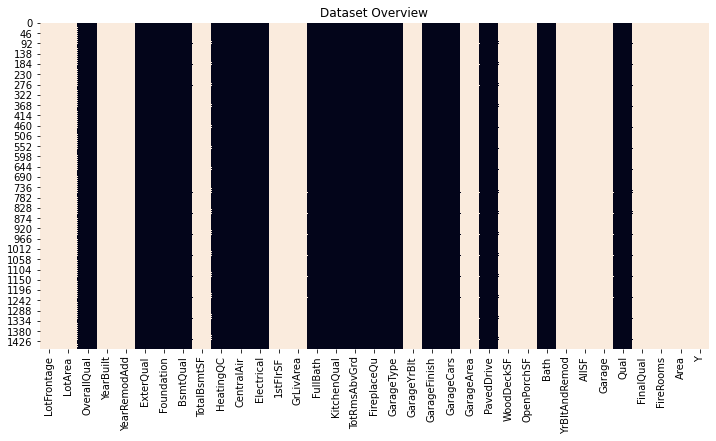

 Categerocial   Numeric   NaN 


In [21]:
# heatmap of missed values, numerical and categoryal

max_cat = 20
dic_cols = {col:utils_recognize_type(df, col, max_cat) for col in df.columns}
heatmap = df.isnull()    
for k,v in dic_cols.items():    
    if v == "num":    
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)    
    else:    
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
sns.heatmap(heatmap, cbar=False).set_title('Dataset Overview')    
plt.show()
print("\033[1;37;40m Categerocial ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")

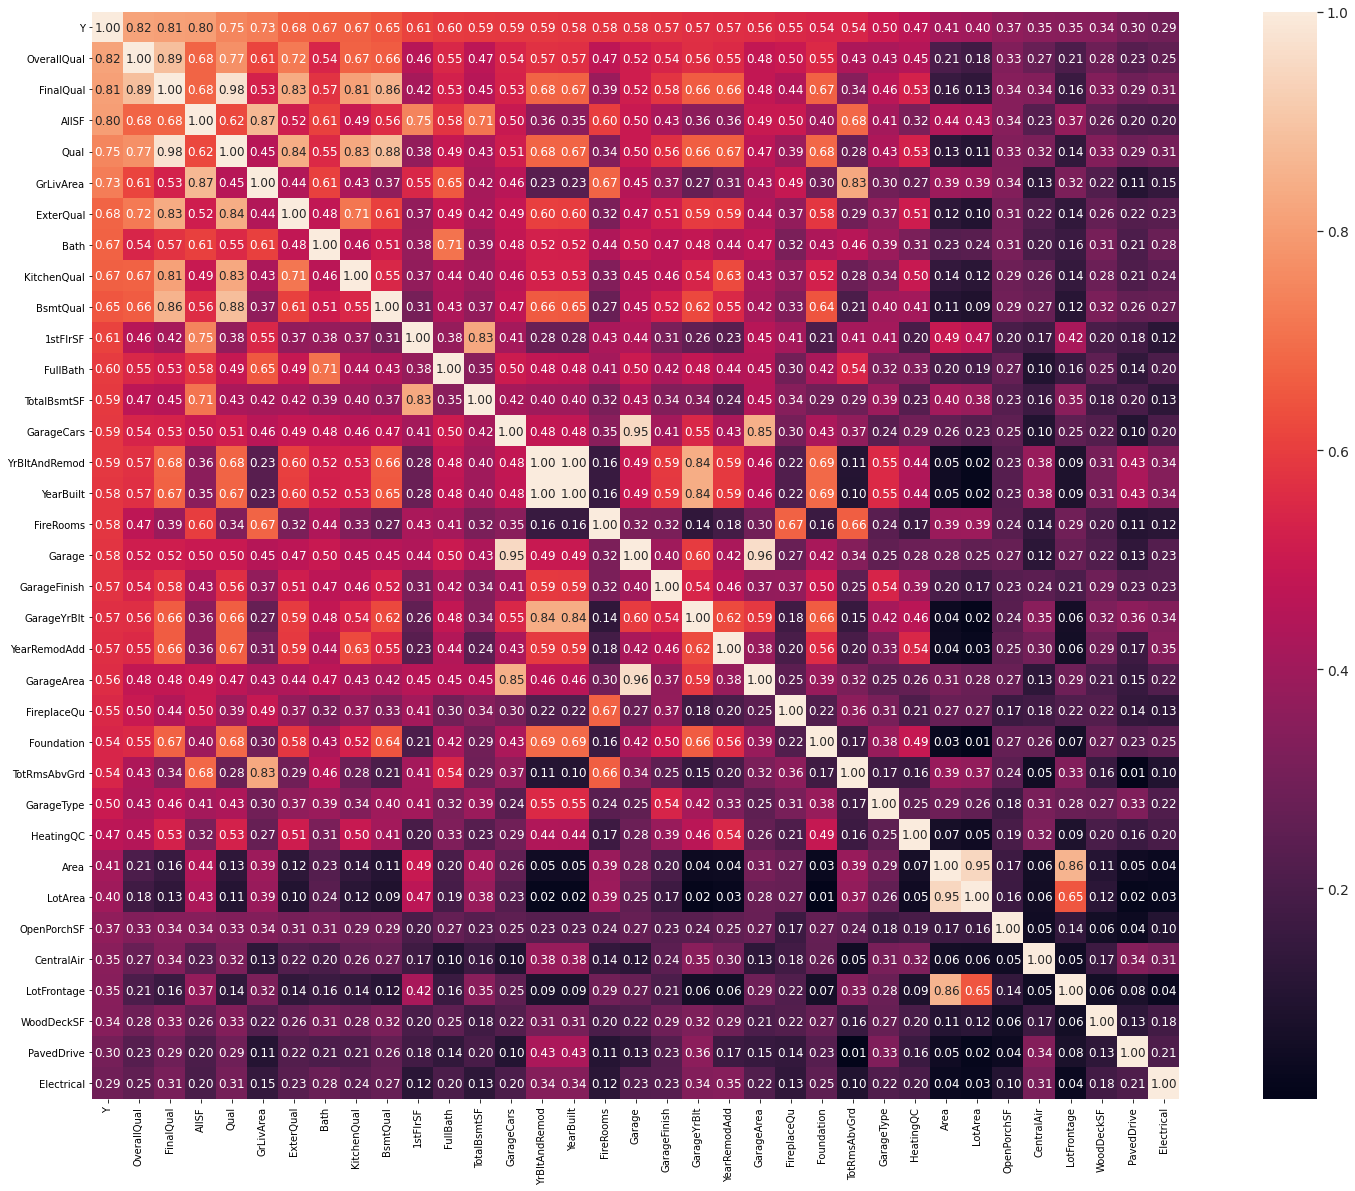

In [22]:
#correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt  # Matlab-style plotting
corrmat = df.corr()
f, ax = plt.subplots(figsize=(30, 20))
#sns.heatmap(corrmat, vmax=.8, square=True);
#saleprice correlation matrix
k = 35 #number of variables for heatmap
cols = corrmat.nlargest(k, 'Y')['Y'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 12}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

EDA

# SalePrice

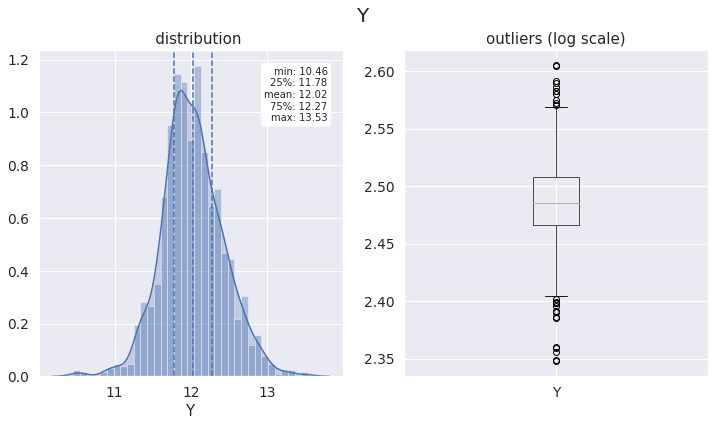

In [23]:
x = "Y"
fig, ax = plt.subplots(nrows=1, ncols=2,  sharex=False, sharey=False)    
fig.suptitle(x, fontsize=20)

### distribution    
ax[0].title.set_text('   distribution')    
variable = df[x].fillna(df[x].mean())    
breaks = np.quantile(variable, q=np.linspace(0, 1, 11))

#variable = variable[ (variable > breaks[quantile_breaks[0]]) & (variable < breaks[quantile_breaks[1]]) ]     
sns.distplot(variable, hist=True, kde=True, kde_kws={"shade": True}, ax=ax[0])    
des = df[x].describe()    
ax[0].axvline(des["25%"], ls='--')    
ax[0].axvline(des["mean"], ls='--')    
ax[0].axvline(des["75%"], ls='--')    
ax[0].grid(True)    
des = round(des, 2).apply(lambda x: str(x))    
box = '\n'.join(("min: "+des["min"], "25%: "+des["25%"], "mean: "+des["mean"], "75%: "+des["75%"], "max: "+des["max"]))    
ax[0].text(0.95, 0.95, box, transform=ax[0].transAxes, fontsize=10, va='top', ha="right", bbox=dict(boxstyle='round', facecolor='white', alpha=1))
### boxplot     
ax[1].title.set_text('outliers (log scale)')    
tmp_df = pd.DataFrame(df[x])    
tmp_df[x] = np.log(tmp_df[x])    
tmp_df.boxplot(column=x, ax=ax[1])    
plt.show()

# FullBath: Full bathrooms above grade(This will be the case of categorical (FullBath) vs numerical (Y))

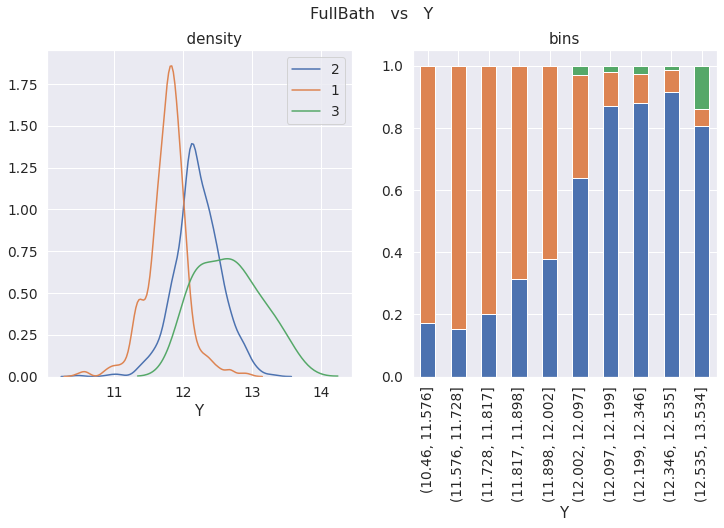

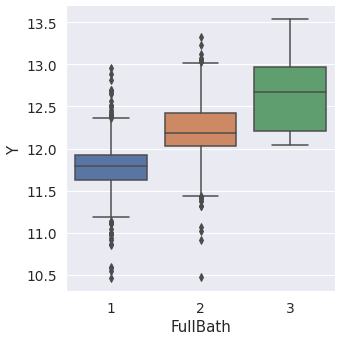

In [24]:
y = "Y"
x = "FullBath"
cat, num = "FullBath", "Y"
fig, ax = plt.subplots(nrows=1, ncols=2,  sharex=False, sharey=False)    
fig.suptitle(x+"   vs   "+y, fontsize=16)

### distribution    
ax[0].title.set_text('      density')    
for i in df[cat].unique():    
    sns.distplot(df[df[cat]==i][num], hist=False, label=i, ax=ax[0])    
ax[0].grid(True)

### stacked    
ax[1].title.set_text('bins')    
breaks = np.quantile(df[num], q=np.linspace(0,1,11))    
tmp = df.groupby([cat, pd.cut(df[num], breaks, duplicates='drop')]).size().unstack().T    
tmp = tmp[df[cat].unique()]    
tmp["tot"] = tmp.sum(axis=1)    
for col in tmp.drop("tot", axis=1).columns:    
     tmp[col] = tmp[col] / tmp["tot"]    
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot       
#ax[2].title.set_text('outliers')    
sns.catplot(x=cat, y=num, data=df, kind="box")    
#ax[2].grid(True)    
#plt.show()

In [25]:
cat, num = "FullBath", "Y"
model = smf.ols(num+' ~ '+cat, data=df).fit()    
table = sm.stats.anova_lm(model)    
p = table["PR(>F)"][0]    
coeff, p = None, round(p, 3)    
conclusion = "Correlated" if p < 0.05 else "Non-Correlated"    
print("Anova F conclusion: FullBath and SalePrice are", conclusion, "(p-value: "+str(p)+")")

Anova F conclusion: FullBath and SalePrice are Correlated (p-value: 0.0)


# GrLivArea: Above grade (ground) living area square feet (numerical  vs numerical )

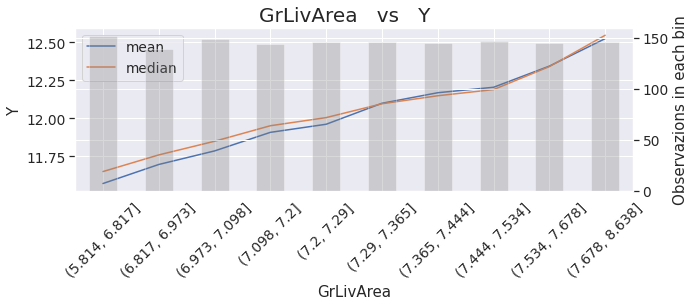

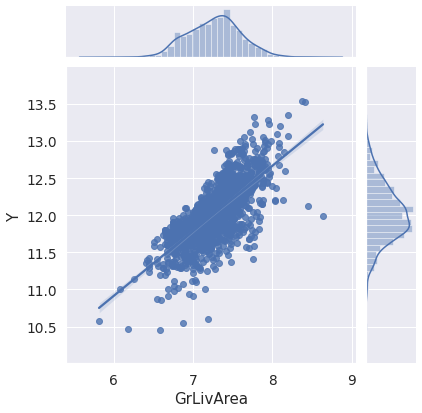

In [26]:
x, y = "GrLivArea", "Y"
### bin plot    
df_noNan = df[df[x].notnull()]    
breaks = np.quantile(df_noNan[x], q=np.linspace(0, 1, 11))    
groups = df_noNan.groupby([pd.cut(df_noNan[x], bins=breaks,     
           duplicates='drop')])[y].agg(['mean','median','size'])    
fig, ax = plt.subplots(figsize=(10,3))    
fig.suptitle(x+"   vs   "+y, fontsize=20)    
groups[["mean", "median"]].plot(kind="line", ax=ax)    
groups["size"].plot(kind="bar", ax=ax, rot=45, secondary_y=True,    
                    color="grey", alpha=0.3, grid=True)    
ax.set(ylabel=y)    
ax.right_ax.set_ylabel("Observazions in each bin")    
plt.show()
### scatter plot    
sns.jointplot(x=x, y=y, data=df, dropna=True, kind='reg')    
plt.show()

In [27]:
x, y = "GrLivArea", "Y"
df_noNan = df[df[x].notnull()]    
coeff, p = scipy.stats.pearsonr(df_noNan[x], df_noNan[y])    
coeff, p = round(coeff, 3), round(p, 3)    
conclusion = "Significant" if p < 0.05 else "Non-Significant"    
print("Pearson Correlation:", coeff, conclusion, "(p-value: "+str(p)+")")

Pearson Correlation: 0.73 Significant (p-value: 0.0)


In [28]:
## split data    
df_train, df_test = model_selection.train_test_split(df, test_size=0.3, random_state=1)

## print info    
print("X_train shape:", df_train.drop("Y",axis=1).shape, "| X_test shape:", df_test.drop("Y",axis=1).shape)    
print("y_train mean:", round(np.mean(df_train["Y"]),2), "| y_test mean:", round(np.mean(df_test["Y"]),2))    
print(df_train.shape[1], "features:", df_train.drop("Y",axis=1).columns.to_list())

X_train shape: (1022, 34) | X_test shape: (438, 34)
y_train mean: 12.03 | y_test mean: 12.0
35 features: ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'ExterQual', 'Foundation', 'BsmtQual', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', 'GrLivArea', 'FullBath', 'KitchenQual', 'TotRmsAbvGrd', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Bath', 'YrBltAndRemod', 'AllSF', 'Garage', 'Qual', 'FinalQual', 'FireRooms', 'Area']


# Checking for multicollinearity features

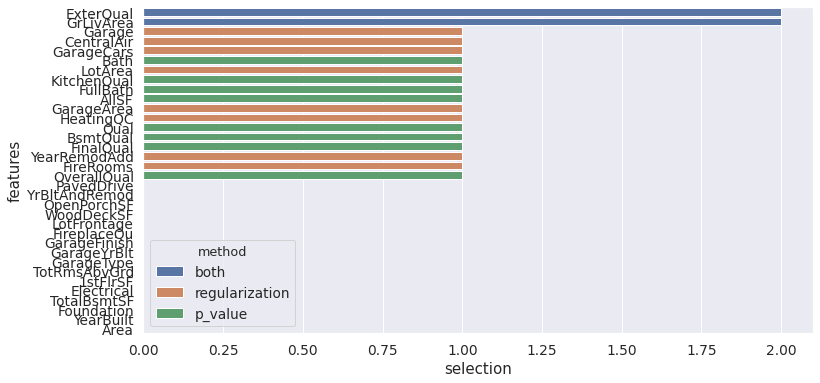

In [29]:
X = df_train.drop("Y", axis=1).values    
y = df_train["Y"].values    
feature_names = df_train.drop("Y", axis=1).columns

## p-value    
selector = feature_selection.SelectKBest(score_func=feature_selection.f_regression, k=10).fit(X,y)    
pvalue_selected_features = feature_names[selector.get_support()]

## regularization    
selector = feature_selection.SelectFromModel(estimator=     
              linear_model.Ridge(alpha=1.0, fit_intercept=True),     
                                 max_features=10).fit(X,y)    
regularization_selected_features = feature_names[selector.get_support()]

## plot  

df_features = pd.DataFrame({"features":feature_names})    
df_features["p_value"] = df_features["features"].apply(lambda x: "p_value" if x in pvalue_selected_features else "")    
df_features["num1"] = df_features["features"].apply(lambda x: 1 if x in pvalue_selected_features else 0)    
df_features["regularization"] = df_features["features"].apply(lambda x: "regularization" if x in regularization_selected_features else "")    
df_features["num2"] = df_features["features"].apply(lambda x: 1 if x in regularization_selected_features else 0)    
df_features["method"] = df_features[["p_value","regularization"]].apply(lambda x: (x[0]+" "+x[1]).strip(), axis=1)    
df_features["selection"] = df_features["num1"] + df_features["num2"]    
df_features["method"] = df_features["method"].apply(lambda x: "both" if len(x.split()) == 2 else x)

sns.barplot(y="features", x="selection", hue="method", data=df_features.sort_values("selection", ascending=False), dodge=False)

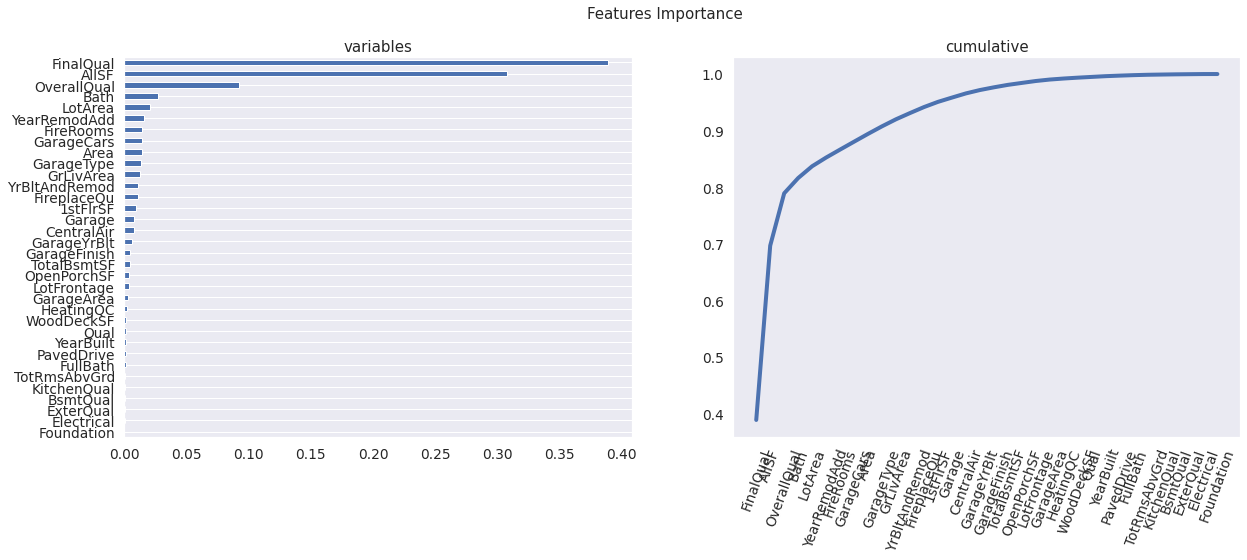

In [30]:
X = df_train.drop("Y", axis=1).values    
y = df_train["Y"].values    
feature_names = df_train.drop("Y", axis=1).columns.tolist()

## call model    
model = ensemble.GradientBoostingRegressor()
## Importance    
model.fit(X,y)    
importances = model.feature_importances_
## Put in a pandas df    
df_importances = pd.DataFrame({"IMPORTANCE":importances,     
            "VARIABLE":feature_names}).sort_values("IMPORTANCE",     
            ascending=False)    
df_importances['cumsum'] = df_importances['IMPORTANCE'].cumsum(axis=0)    
df_importances = df_importances.set_index("VARIABLE")
## Plot    
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(20, 7)) 
fig.suptitle("Features Importance", fontsize=15)    
ax[0].title.set_text('variables')    
df_importances[["IMPORTANCE"]].sort_values(by="IMPORTANCE").plot(    
                kind="barh", legend=False, ax=ax[0]).grid(axis="x")    
ax[0].set(ylabel="")    
ax[1].title.set_text('cumulative')    
df_importances[["cumsum"]].plot(kind="line", linewidth=4,     
                                 legend=False, ax=ax[1])    
ax[1].set(xlabel="", xticks=np.arange(len(df_importances)),     
          xticklabels=df_importances.index)    
plt.xticks(rotation=70)    
plt.grid(axis='both') 
plt.show()

# Modelling

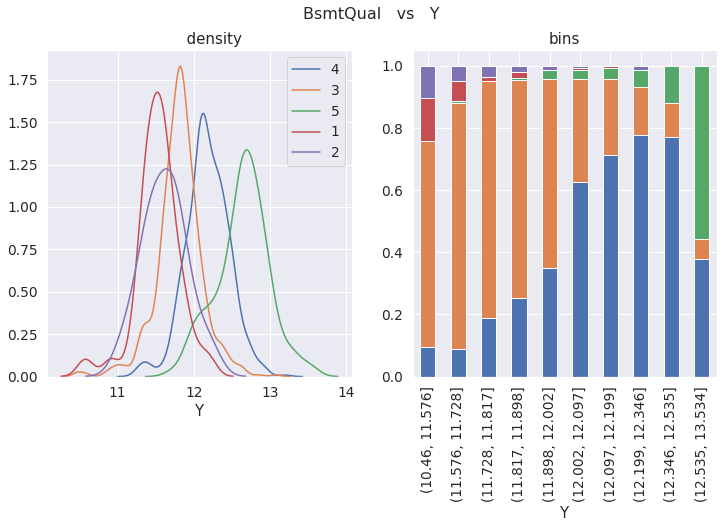

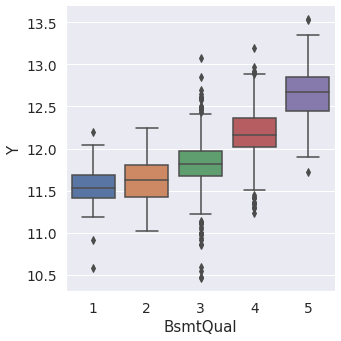

In [31]:
y = "Y"
x = "BsmtQual"
cat, num = "BsmtQual", "Y"
fig, ax = plt.subplots(nrows=1, ncols=2,  sharex=False, sharey=False)    
fig.suptitle(x+"   vs   "+y, fontsize=16)

### distribution    
ax[0].title.set_text('      density')    
for i in df[cat].unique():    
    sns.distplot(df[df[cat]==i][num], hist=False, label=i, ax=ax[0])    
ax[0].grid(True)

### stacked    
ax[1].title.set_text('bins')    
breaks = np.quantile(df[num], q=np.linspace(0,1,11))    
tmp = df.groupby([cat, pd.cut(df[num], breaks, duplicates='drop')]).size().unstack().T    
tmp = tmp[df[cat].unique()]    
tmp["tot"] = tmp.sum(axis=1)    
for col in tmp.drop("tot", axis=1).columns:    
     tmp[col] = tmp[col] / tmp["tot"]    
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot       
#ax[2].title.set_text('outliers')    
sns.catplot(x=cat, y=num, data=df, kind="box")    
#ax[2].grid(True)    
#plt.show()

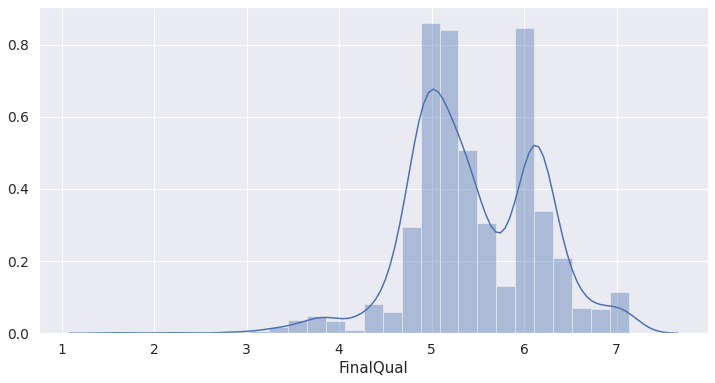

In [32]:
sns.distplot(df['FinalQual'])

In [33]:
X_names = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'ExterQual', 'Foundation', 'BsmtQual', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', 'GrLivArea', 'FullBath', 'KitchenQual', 'TotRmsAbvGrd', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Bath', 'YrBltAndRemod', 'AllSF', 'Garage', 'Qual', 'FinalQual', 'FireRooms', 'Area']

X_train = df_train[X_names].values    
y_train = df_train["Y"].values
X_test = df_test[X_names].values    
y_test = df_test["Y"].values

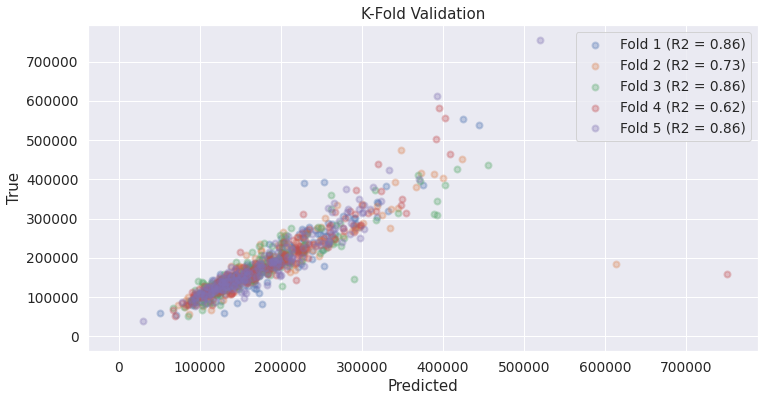

In [34]:
## call model    
model = linear_model.LinearRegression(normalize=True)
## K fold validation    
scores = []    
cv = model_selection.KFold(n_splits=5, shuffle=True)    
fig = plt.figure()    
i = 1    
for train, test in cv.split(X_train, y_train):    
    prediction = np.expm1(model.fit(X_train[train], y_train[train]).predict(X_train[test]))  
    true = np.expm1(y_train[test])   
    score = metrics.r2_score(true, prediction)    
    scores.append(score)    
    plt.scatter(prediction, true, lw=2, alpha=0.3, label='Fold %d (R2 = %0.2f)' % (i,score))    
    i = i+1    
plt.plot([min(y_train),max(y_train)], [min(y_train),max(y_train)], linestyle='--', lw=2, color='black')    
plt.xlabel('Predicted')    
plt.ylabel('True')    
plt.title('K-Fold Validation')    
plt.legend()    
plt.show()

In [35]:
## train    
model.fit(X_train, y_train)
## test    
predicted = np.expm1(model.predict(X_test))

In [36]:
## Kpi    
print("R2 (explained variance):", round(metrics.r2_score(np.expm1(y_test), predicted), 2))    
print("Mean Absolute Perc Error (Σ(|y-pred|/y)/n):", round(np.mean(np.abs((np.expm1(y_test)-predicted)/predicted)), 2))    
print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.0f}".format(metrics.mean_absolute_error(np.expm1(y_test), predicted)))    
print("Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)):", "{:,.0f}".format(np.sqrt(metrics.mean_squared_error(np.expm1(y_test), predicted))))## residuals    
residuals = np.expm1(y_test) - predicted    
max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)    
max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(residuals).index(min(residuals))    
max_true, max_pred = y_test[max_idx], predicted[max_idx]    
print("Max Error:", "{:,.0f}".format(max_error))

R2 (explained variance): 0.9
Mean Absolute Perc Error (Σ(|y-pred|/y)/n): 0.1
Mean Absolute Error (Σ|y-pred|/n): 17,568
Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)): 26,875
Max Error: 252,484


In [37]:
df_test_main.Id

0       1461
1       1462
2       1463
3       1464
4       1465
        ... 
1454    2915
1455    2916
1456    2917
1457    2918
1458    2919
Name: Id, Length: 1459, dtype: int64

In [38]:
predicted = np.expm1(model.predict(X_test_fin[X_names].values))
solution = pd.DataFrame({"Id":df_test_main.Id, "SalePrice":predicted})
solution.to_csv("/kaggle/working/solution.csv", index = False)

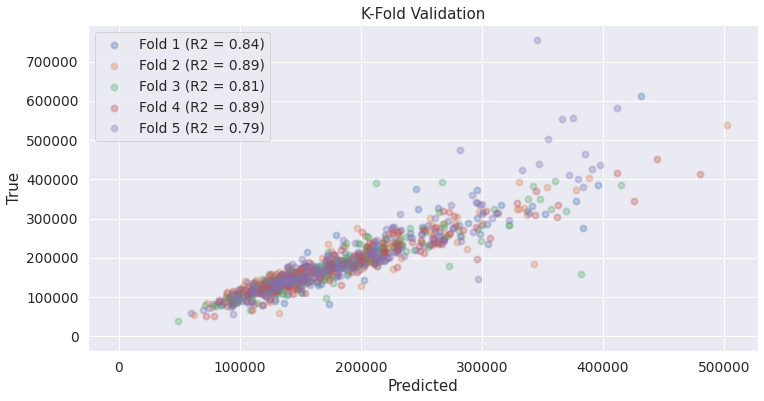

In [39]:
## call model    
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
## K fold validation    
scores = []    
cv = model_selection.KFold(n_splits=5, shuffle=True)    
fig = plt.figure()    
i = 1    
for train, test in cv.split(X_train, y_train):    
    prediction = np.expm1(model.fit(X_train[train], y_train[train]).predict(X_train[test]))    
    true = np.expm1(y_train[test])   
    score = metrics.r2_score(true, prediction)    
    scores.append(score)    
    plt.scatter(prediction, true, lw=2, alpha=0.3, label='Fold %d (R2 = %0.2f)' % (i,score))    
    i = i+1    
plt.plot([min(y_train),max(y_train)], [min(y_train),max(y_train)], linestyle='--', lw=2, color='black')    
plt.xlabel('Predicted')    
plt.ylabel('True')    
plt.title('K-Fold Validation')    
plt.legend()    
plt.show()

In [40]:
model.fit(X_train, y_train,              early_stopping_rounds=5, 
             eval_set=[(X_test, y_test)],
             verbose=False)
predicted = np.expm1(model.predict(X_test))

In [41]:
## Kpi    
print("R2 (explained variance):", round(metrics.r2_score(np.expm1(y_test), predicted), 2))    
print("Mean Absolute Perc Error (Σ(|y-pred|/y)/n):", round(np.mean(np.abs((np.expm1(y_test)-predicted)/predicted)), 2))  
print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.0f}".format(metrics.mean_absolute_error(np.expm1(y_test), predicted)))    
print("Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)):", "{:,.0f}".format(np.sqrt(metrics.mean_squared_error(np.expm1(y_test), predicted))))## residuals    
residuals = np.expm1(y_test) - predicted    
max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)    
max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(residuals).index(min(residuals))    
max_true, max_pred = y_test[max_idx], predicted[max_idx]    
print("Max Error:", "{:,.0f}".format(max_error))

R2 (explained variance): 0.87
Mean Absolute Perc Error (Σ(|y-pred|/y)/n): 0.1
Mean Absolute Error (Σ|y-pred|/n): 18,105
Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)): 30,366
Max Error: 340,927


In [42]:
## Plot predicted vs true    
#fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))    
#from statsmodels.graphics.api import abline_plot    
#ax[0].scatter(predicted, y_test, color="black")    
#abline_plot(intercept=0, slope=1, color="red", ax=ax[0])    
#ax[0].vlines(x=max_pred, ymin=max_true, ymax=max_true-max_error, color='red', linestyle='--', alpha=0.7, label="max error")    
#ax[0].grid(True)    
#ax[0].set(xlabel="Predicted", ylabel="True", title="Predicted vs True")    
#ax[0].legend()
## Plot predicted vs residuals    
#ax[1].scatter(predicted, residuals, color="red")    
#ax[1].vlines(x=max_pred, ymin=0, ymax=max_error, color='black', linestyle='--', alpha=0.7, label="max error")    
#ax[1].grid(True)    
#ax[1].set(xlabel="Predicted", ylabel="Residuals", title="Predicted vs Residuals")    
#ax[1].hlines(y=0, xmin=np.min(predicted), xmax=np.max(predicted))    
#ax[1].legend()    
#plt.show()

In [43]:
#fig, ax = plt.subplots()    
#sns.distplot(residuals, color="red", hist=True, kde=True, kde_kws={"shade":True}, ax=ax)    
#ax.grid(True)    
#ax.set(yticks=[], yticklabels=[], title="Residuals distribution")    
#plt.show()

In [44]:
#print("True:", "{:,.0f}".format(y_test[1]), "--> Pred:", "{:,.0f}".format(predicted[1]))

In [45]:
#explainer = lime_tabular.LimeTabularExplainer(training_data=X_train, feature_names=X_names, class_names="Y", mode="regression")    
#explained = explainer.explain_instance(X_test[1], model.predict, num_features=10)    
#explained.as_pyplot_figure()